1. **global air pollution dataset.csv**
2. **climate_change_impact_on_agriculture_2024.csv**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df1 = pd.read_csv("climate_change_impact_on_agriculture_2024.csv")

df1.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [3]:
print(df1.shape)

(10000, 15)


In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strate

In [5]:
df1.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2007.088700,15.241299,1611.663834,15.246608,2.240017,4.980900,55.248332,24.955735,49.973708,64.901278,674.269658
std,10.084245,11.466955,805.016815,8.589423,0.998342,3.165808,25.988305,14.490962,28.711027,20.195882,414.591431
min,1990.000000,-4.990000,200.150000,0.500000,0.450000,0.000000,10.010000,0.000000,0.010000,30.000000,47.840000
25%,1999.000000,5.430000,925.697500,7.760000,1.449000,2.000000,32.677500,12.527500,25.390000,47.235000,350.545000
50%,2007.000000,15.175000,1611.160000,15.200000,2.170000,5.000000,55.175000,24.930000,49.635000,64.650000,583.920000
75%,2016.000000,25.340000,2306.997500,22.820000,2.930000,8.000000,77.582500,37.470000,74.825000,82.472500,917.505000
max,2024.000000,35.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,2346.470000


In [6]:
df1.dtypes

,0
Year,int64
Country,object
Region,object
Crop_Type,object
Average_Temperature_C,float64
Total_Precipitation_mm,float64
CO2_Emissions_MT,float64
Crop_Yield_MT_per_HA,float64
Extreme_Weather_Events,int64
Irrigation_Access_%,float64


In [7]:
df1.isnull().sum()

,0
Year,0
Country,0
Region,0
Crop_Type,0
Average_Temperature_C,0
Total_Precipitation_mm,0
CO2_Emissions_MT,0
Crop_Yield_MT_per_HA,0
Extreme_Weather_Events,0
Irrigation_Access_%,0


Missing values are checked before analysis because they can affect data quality and machine learning model performance.

In [8]:
# Numerical Columns

df1["Average_Temperature_C"] = df1["Average_Temperature_C"].fillna(df1["Average_Temperature_C"].mean())

df1["Soil_Health_Index"] = df1["Soil_Health_Index"].fillna(df1["Soil_Health_Index"].mean())

# Categorical Columns

df1["Crop_Type"] = df1["Crop_Type"].fillna(df1["Crop_Type"].mode()[0])

df1["Adaptation_Strategies"] = df1["Adaptation_Strategies"].fillna(df1["Adaptation_Strategies"].mode()[0])

- Numerical missing values were replaced using the mean.

- Categorical missing values were replaced using the mode because it represents the most frequently occurring category.

The dataset contains climate, environmental, and agricultural information collected from different countries and regions.

Each record represents the impact of climate-related factors on crop production and the economy.

The dataset helps analyze how climate change affects agriculture and supports sustainable farming practices.

## Features Description

- Year → Year of observation
- Country → Country name
- Region → Geographical region
- Crop_Type → Type of crop
- Average_Temperature_C → Average annual temperature
- Total_Precipitation_mm → Total rainfall received
- CO2_Emissions_MT → Carbon dioxide emissions
- Crop_Yield_MT_per_HA → Crop production per hectare (Target Variable)
- Extreme_Weather_Events → Number of climate disasters
- Irrigation_Access_% → Percentage of irrigation availability
- Pesticide_Use_KG_per_HA → Pesticide usage
- Fertilizer_Use_KG_per_HA → Fertilizer usage
- Soil_Health_Index → Soil quality score
- Adaptation_Strategies → Climate adaptation methods
- Economic_Impact_Million_USD → Economic impact due to climate change

In [9]:
# Feature 1

df1["Yield_per_Rainfall"] = (
    df1["Crop_Yield_MT_per_HA"] /
    df1["Total_Precipitation_mm"]
)

# Feature 2

df1["Fertilizer_Efficiency"] = (
    df1["Crop_Yield_MT_per_HA"] /
    df1["Fertilizer_Use_KG_per_HA"]
)

# Feature 3

df1["Climate_Risk_Index"] = (
    df1["Average_Temperature_C"] *
    df1["CO2_Emissions_MT"] *
    df1["Extreme_Weather_Events"]
)

df1.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Yield_per_Rainfall,Fertilizer_Efficiency,Climate_Risk_Index
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13,0.003885,0.117524,188.7280
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22,0.000596,0.074710,770.5488
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96,0.001321,0.026232,2717.9125
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32,0.003370,0.044417,1936.9675
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72,0.000664,0.012262,232.7751


Three new features were created.

• Yield_per_Rainfall measures agricultural productivity based on rainfall.

• Fertilizer_Efficiency measures crop production achieved per kilogram of fertilizer.

• Climate_Risk_Index estimates the combined impact of temperature, carbon emissions, and extreme weather events.

In [10]:
print(df1.groupby("Crop_Type")["Crop_Yield_MT_per_HA"].mean())

Crop_Type
Barley        2.285337
Coffee        2.224206
Corn          2.223170
Cotton        2.171580
Fruits        2.293362
Rice          2.249131
Soybeans      2.226682
Sugarcane     2.263790
Vegetables    2.201579
Wheat         2.266631
Name: Crop_Yield_MT_per_HA, dtype: float64


- Different crop types produce different average yields.

- Crop productivity depends upon the crop variety.

In [11]:
print(df1.groupby("Region")["Average_Temperature_C"].mean())

Region
British Columbia              14.539959
Central                       14.977897
East                          14.749853
Grand Est                     15.299370
Ile-de-France                 14.734110
Maharashtra                   14.578869
Midwest                       16.602055
New South Wales               15.475145
North                         15.978779
North Central                 13.527745
North West                    15.733788
Northeast                     15.794481
Northwest                     15.489676
Northwestern                  16.085507
Nouvelle-Aquitaine            15.813810
Ontario                       15.054275
Pampas                        14.283929
Patagonia                     14.873614
Prairies                      15.636091
Provence-Alpes-Cote d’Azur    15.729576
Punjab                        13.866319
Quebec                        16.349913
Queensland                    14.538775
Siberian                      14.069309
South                         15.

- Average temperature varies across different regions because of geographical differences.

In [12]:
print(df1.groupby("Country")["CO2_Emissions_MT"].mean())

Country
Argentina    15.368902
Australia    15.396909
Brazil       15.020392
Canada       15.641900
China        15.025538
France       15.467822
India        15.075951
Nigeria      14.896569
Russia       15.221852
USA          15.362510
Name: CO2_Emissions_MT, dtype: float64


- Different countries produce different amounts of CO₂ emissions depending on industrial and agricultural activities.

In [13]:
print(df1.groupby("Region")["Irrigation_Access_%"].mean())

Region
British Columbia              56.450455
Central                       54.270300
East                          52.574505
Grand Est                     55.016614
Ile-de-France                 56.216653
Maharashtra                   57.210814
Midwest                       53.705573
New South Wales               55.980543
North                         54.740553
North Central                 56.238894
North West                    52.098106
Northeast                     54.675253
Northwest                     55.880729
Northwestern                  52.737093
Nouvelle-Aquitaine            51.558254
Ontario                       55.420632
Pampas                        55.871295
Patagonia                     55.574297
Prairies                      57.403169
Provence-Alpes-Cote d’Azur    57.548390
Punjab                        54.318715
Quebec                        55.750696
Queensland                    55.947273
Siberian                      58.982602
South                         55.

- Regions with better irrigation facilities generally support higher agricultural productivity.

In [14]:
print(df1[["Average_Temperature_C","Crop_Yield_MT_per_HA"]].corr())

                       Average_Temperature_C  Crop_Yield_MT_per_HA
Average_Temperature_C               1.000000              0.263781
Crop_Yield_MT_per_HA                0.263781              1.000000


- This correlation helps understand whether temperature positively or negatively affects crop yield.

In [15]:
print(df1[["Total_Precipitation_mm","Crop_Yield_MT_per_HA"]].corr())

                        Total_Precipitation_mm  Crop_Yield_MT_per_HA
Total_Precipitation_mm                1.000000              0.029728
Crop_Yield_MT_per_HA                  0.029728              1.000000


- Rainfall plays an important role in agricultural productivity.

- Adequate rainfall generally improves crop production.

In [16]:
print(df1[["Fertilizer_Use_KG_per_HA","Crop_Yield_MT_per_HA"]].corr())

                          Fertilizer_Use_KG_per_HA  Crop_Yield_MT_per_HA
Fertilizer_Use_KG_per_HA                  1.000000              0.006423
Crop_Yield_MT_per_HA                      0.006423              1.000000


- Appropriate fertilizer application improves crop yield.

- Excessive fertilizer use may not always increase productivity.

In [17]:
print(df1[["Soil_Health_Index","Crop_Yield_MT_per_HA"]].corr())

                      Soil_Health_Index  Crop_Yield_MT_per_HA
Soil_Health_Index              1.000000             -0.005692
Crop_Yield_MT_per_HA          -0.005692              1.000000


- Healthy soil generally supports better crop production.

In [18]:
print(df1[["CO2_Emissions_MT","Average_Temperature_C"]].corr())

                       CO2_Emissions_MT  Average_Temperature_C
CO2_Emissions_MT               1.000000              -0.003052
Average_Temperature_C         -0.003052               1.000000


- Carbon dioxide emissions may influence changes in average temperature.

In [19]:
print(df1[["Irrigation_Access_%","Crop_Yield_MT_per_HA"]].corr())

                      Irrigation_Access_%  Crop_Yield_MT_per_HA
Irrigation_Access_%              1.000000             -0.000255
Crop_Yield_MT_per_HA            -0.000255              1.000000


- Improved irrigation access generally contributes to better crop yield.

In [20]:
print(df1[["Extreme_Weather_Events","Economic_Impact_Million_USD"]].corr())

                             Extreme_Weather_Events  \
Extreme_Weather_Events                     1.000000   
Economic_Impact_Million_USD               -0.004526   

                             Economic_Impact_Million_USD  
Extreme_Weather_Events                         -0.004526  
Economic_Impact_Million_USD                     1.000000  


- More extreme weather events often increase the economic losses in agriculture.

In [21]:
print(df1.groupby("Adaptation_Strategies")["Economic_Impact_Million_USD"].mean())

Adaptation_Strategies
Crop Rotation              685.324149
Drought-resistant Crops    686.226637
No Adaptation              677.879363
Organic Farming            663.542228
Water Management           658.843997
Name: Economic_Impact_Million_USD, dtype: float64


- Different adaptation strategies have different impacts on reducing economic losses caused by climate change.

In [22]:
print(df1.sort_values("Crop_Yield_MT_per_HA",ascending=False).head(10))

      Year    Country           Region   Crop_Type  Average_Temperature_C  \
3629  1994    Nigeria       South East      Barley                  12.15   
9864  2020     Brazil        Southeast        Rice                  17.54   
8611  2011  Australia  New South Wales    Soybeans                  19.39   
8700  1993      China             East        Rice                  11.90   
9187  2018     Russia         Siberian        Corn                  13.66   
4235  1993     Russia     Northwestern  Vegetables                  16.39   
9011  2015  Australia         Victoria      Coffee                  14.73   
8717  2008     France        Grand Est       Wheat                  17.23   
2014  1996    Nigeria       North West   Sugarcane                  17.72   
5765  1995     Canada           Quebec        Corn                  13.36   

      Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
3629                 2461.41             13.82                  5.00   
9864    

- These records represent the highest crop yields in the dataset.

In [23]:
print(df1.sort_values("Economic_Impact_Million_USD",ascending=False).head(10))

      Year    Country         Region  Crop_Type  Average_Temperature_C  \
4704  1998      India         Punjab  Sugarcane                  19.92   
6763  2015     Russia       Siberian     Barley                  13.95   
3272  2017      India     Tamil Nadu      Wheat                  16.79   
8683  2012    Nigeria     South West  Sugarcane                  14.66   
4956  2019  Australia       Victoria  Sugarcane                  11.64   
7209  1990        USA        Midwest  Sugarcane                  18.76   
8762  1997    Nigeria  North Central     Cotton                  18.68   
3547  1996     Canada        Ontario       Rice                  18.58   
1090  2008        USA           West       Corn                  10.81   
6567  2018     Russia        Central     Coffee                  18.74   

      Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
4704                 1248.01              6.12                  4.96   
6763                 2110.20             

- These records experienced the highest economic losses due to climate-related factors.

In [24]:
print(df1.corr(numeric_only=True))

                                 Year  Average_Temperature_C  \
Year                         1.000000              -0.004583   
Average_Temperature_C       -0.004583               1.000000   
Total_Precipitation_mm       0.006551               0.007213   
CO2_Emissions_MT            -0.005461              -0.003052   
Crop_Yield_MT_per_HA         0.010734               0.263781   
Extreme_Weather_Events      -0.002726              -0.016808   
Irrigation_Access_%          0.000938              -0.013268   
Pesticide_Use_KG_per_HA     -0.004332               0.005764   
Fertilizer_Use_KG_per_HA     0.013132              -0.014725   
Soil_Health_Index           -0.006294              -0.010841   
Economic_Impact_Million_USD  0.012419               0.195827   
Yield_per_Rainfall           0.003555               0.107238   
Fertilizer_Efficiency       -0.011847              -0.002759   
Climate_Risk_Index          -0.003122               0.536510   

                             Total_Prec

- The correlation matrix helps identify positive, negative, and weak relationships among numerical variables.

- It is useful before building machine learning models.

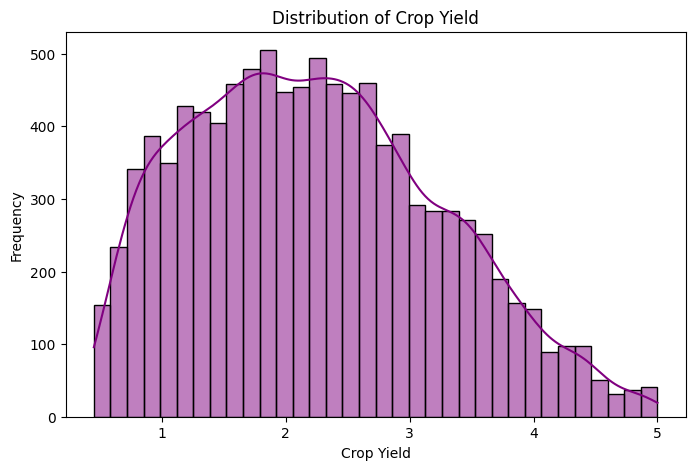

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df1["Crop_Yield_MT_per_HA"],
    kde=True,
    color="purple"
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Crop Yield")
plt.ylabel("Frequency")

plt.show()

- The histogram shows the distribution of crop yield values and helps identify whether the data is normally distributed or skewed.

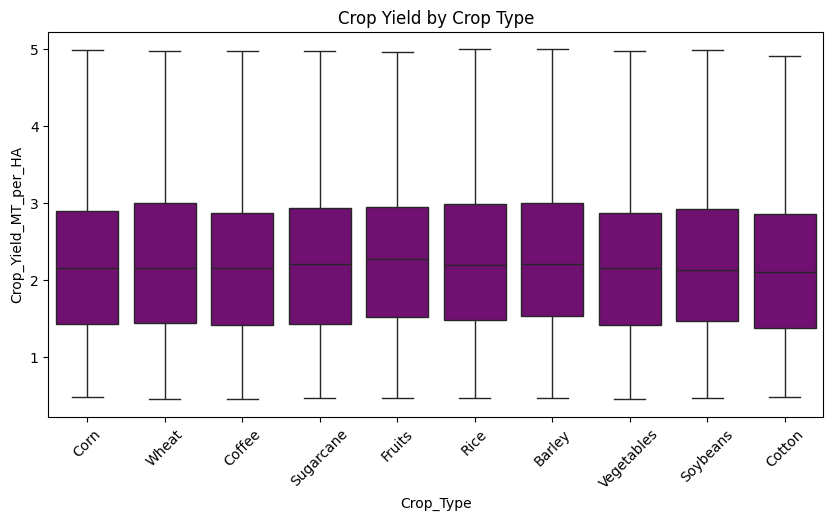

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Crop_Type",
    y="Crop_Yield_MT_per_HA",
    data=df1,
    color="purple"
)

plt.xticks(rotation=45)

plt.title("Crop Yield by Crop Type")

plt.show()

- The boxplot compares crop yield among different crop types and helps detect variability and outliers.

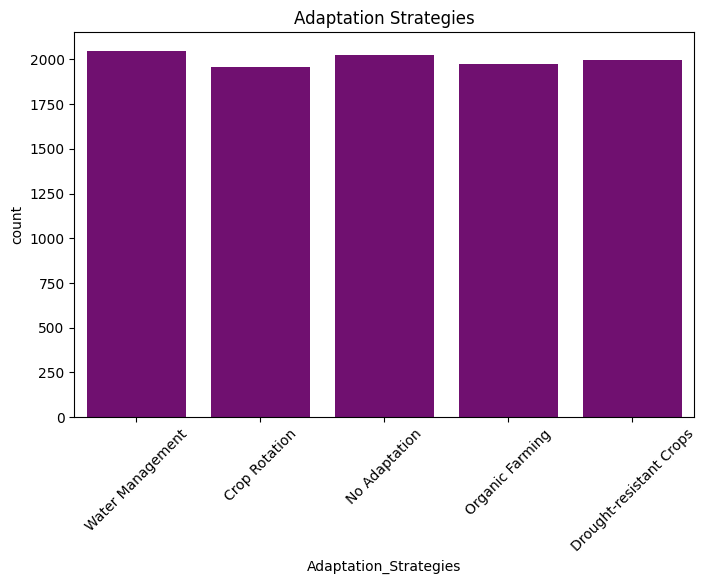

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Adaptation_Strategies",
    data=df1,
    color="purple"
)

plt.xticks(rotation=45)

plt.title("Adaptation Strategies")

plt.show()

- This plot shows the number of records belonging to each adaptation strategy.

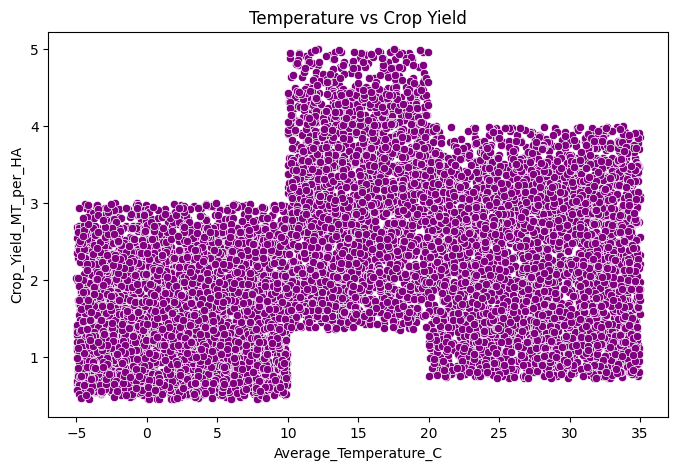

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Average_Temperature_C",
    y="Crop_Yield_MT_per_HA",
    data=df1,
    color="purple"
)

plt.title("Temperature vs Crop Yield")

plt.show()

- The scatter plot helps identify whether temperature has any relationship with crop yield.

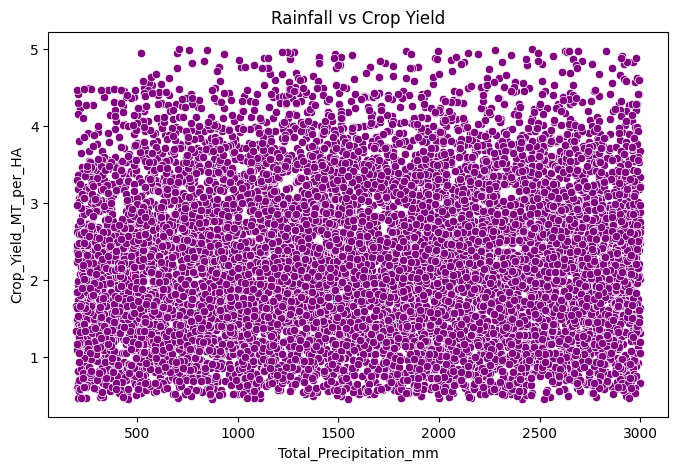

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Total_Precipitation_mm",
    y="Crop_Yield_MT_per_HA",
    data=df1,
    color="purple"
)

plt.title("Rainfall vs Crop Yield")

plt.show()

- Rainfall influences agricultural productivity and may positively affect crop yield.

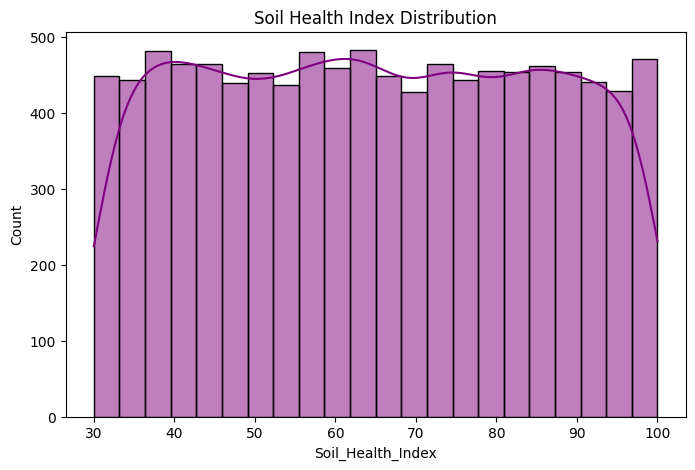

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    df1["Soil_Health_Index"],
    kde=True,
    color="purple"
)

plt.title("Soil Health Index Distribution")

plt.show()

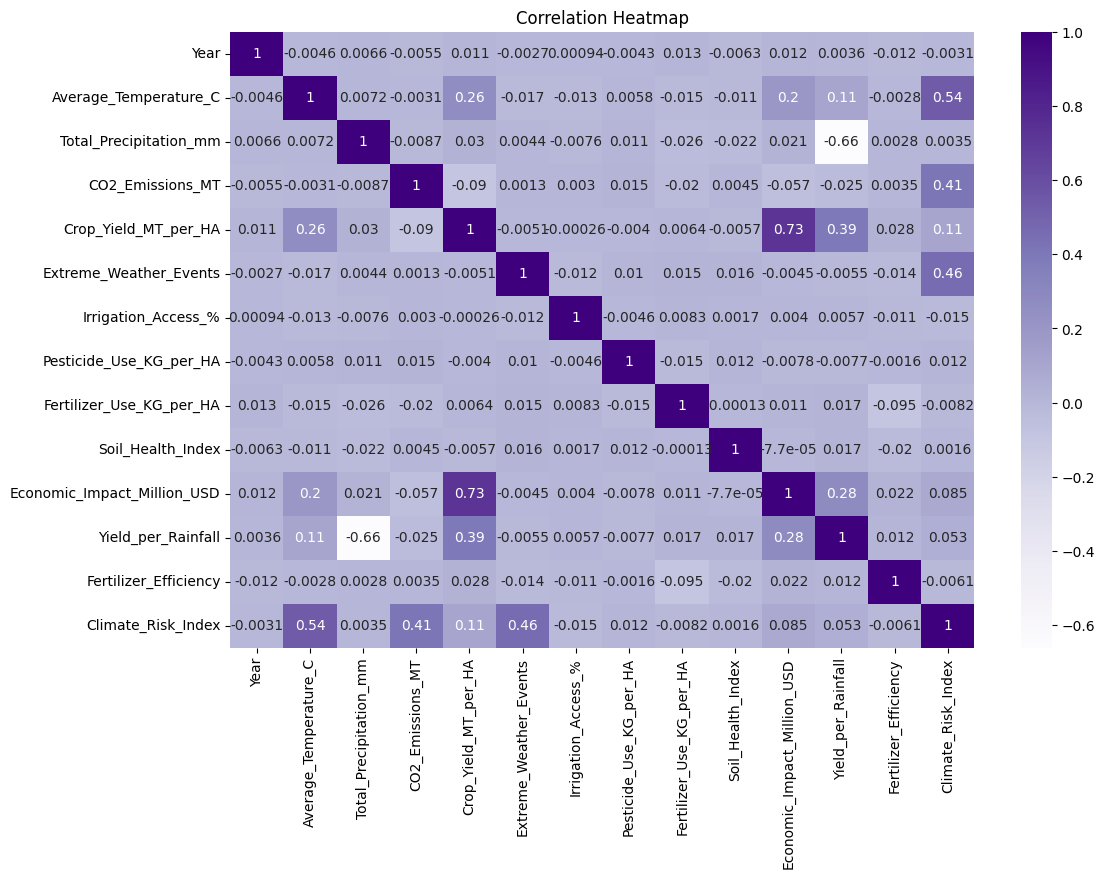

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap="Purples"
)

plt.title("Correlation Heatmap")

plt.show()

- The heatmap shows positive and negative correlations among numerical variables.

In [32]:
scaler = StandardScaler()

num_cols = [
    "Average_Temperature_C",
    "Total_Precipitation_mm",
    "CO2_Emissions_MT",
    "Extreme_Weather_Events",
    "Irrigation_Access_%",
    "Pesticide_Use_KG_per_HA",
    "Fertilizer_Use_KG_per_HA",
    "Soil_Health_Index",
    "Economic_Impact_Million_USD",
    "Yield_per_Rainfall",
    "Fertilizer_Efficiency",
    "Climate_Risk_Index"
]

df1[num_cols] = scaler.fit_transform(df1[num_cols])

df1.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Yield_per_Rainfall,Fertilizer_Efficiency,Climate_Risk_Index
0,2001,India,West Bengal,Corn,-1.194038,-1.446755,-0.003098,1.737,0.953706,-1.566488,-1.026604,-1.225852,0.908583,Water Management,0.322889,0.837420,-0.027961,-0.601780
1,2024,China,North,Corn,-1.047523,1.617322,1.696752,1.737,0.953706,-1.700786,0.559291,-0.930829,-0.538814,Crop Rotation,-0.140024,-0.701175,-0.043590,-0.236551
2,2001,France,Ile-de-France,Wheat,0.511818,-0.385010,1.222890,1.719,0.006034,1.122548,0.169374,0.541850,0.142547,Water Management,0.295946,-0.362338,-0.061288,0.985876
3,2001,Canada,Prairies,Coffee,1.099623,-0.568096,-0.155619,3.890,0.006034,1.493503,-0.729852,1.309886,1.311656,No Adaptation,0.279929,0.596260,-0.054649,0.495650
4,1998,India,Tamil Nadu,Sugarcane,-1.138223,0.019648,-0.400118,1.080,1.269597,1.558535,1.338437,1.327302,-0.757186,Crop Rotation,-0.657426,-0.669635,-0.066388,-0.574130


- Feature scaling standardizes numerical values so that all features have a similar scale, improving machine learning performance.

In [33]:
encoder = LabelEncoder()

cat_cols = [
    "Country",
    "Region",
    "Crop_Type",
    "Adaptation_Strategies"
]

for col in cat_cols:
    df1[col] = encoder.fit_transform(df1[col])

df1.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Yield_per_Rainfall,Fertilizer_Efficiency,Climate_Risk_Index
0,2001,6,32,2,-1.194038,-1.446755,-0.003098,1.737,0.953706,-1.566488,-1.026604,-1.225852,0.908583,4,0.322889,0.837420,-0.027961,-0.601780
1,2024,4,8,2,-1.047523,1.617322,1.696752,1.737,0.953706,-1.700786,0.559291,-0.930829,-0.538814,0,-0.140024,-0.701175,-0.043590,-0.236551
2,2001,5,4,9,0.511818,-0.385010,1.222890,1.719,0.006034,1.122548,0.169374,0.541850,0.142547,4,0.295946,-0.362338,-0.061288,0.985876
3,2001,3,18,1,1.099623,-0.568096,-0.155619,3.890,0.006034,1.493503,-0.729852,1.309886,1.311656,2,0.279929,0.596260,-0.054649,0.495650
4,1998,6,28,7,-1.138223,0.019648,-0.400118,1.080,1.269597,1.558535,1.338437,1.327302,-0.757186,0,-0.657426,-0.669635,-0.066388,-0.574130


- Categorical features were converted into numerical values using LabelEncoder because machine learning algorithms require numerical input.

In [34]:
X = df1.drop("Crop_Yield_MT_per_HA", axis=1)

y = df1["Crop_Yield_MT_per_HA"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 17)
(2000, 17)


- The dataset has been divided into training and testing sets.

- 80% of the data is used for training, while 20% is used to evaluate model performance.

In [35]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [36]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 0.4936217225205658
MSE : 0.39201015583664195
RMSE : 0.6261071440549468
R2 Score : 0.6285925291070453


## Model Insights

• MAE measures the average prediction error.

• MSE penalizes larger prediction errors.

• RMSE represents the average prediction error in the same unit as the target variable.

• R² Score indicates how well the model explains the variation in crop yield.

A lower MAE, MSE, and RMSE together with a higher R² Score indicates better model performance.

## Linear Regression Summary

The Climate Change Impact on Agriculture dataset was successfully analyzed and preprocessed.

Missing values were handled, new features were created, data visualization was performed, numerical data was scaled, categorical data was encoded, and a Linear Regression model was trained.

The model was evaluated using MAE, MSE, RMSE, and R² Score to measure prediction accuracy.

In [37]:
df2 = pd.read_csv("global air pollution dataset.csv")

print(df2.columns)

Index(['Country', 'City', 'AQI Value', 'AQI Category', 'CO AQI Value',
       'CO AQI Category', 'Ozone AQI Value', 'Ozone AQI Category',
       'NO2 AQI Value', 'NO2 AQI Category', 'PM2.5 AQI Value',
       'PM2.5 AQI Category'],
      dtype='object')


In [38]:
print(df2.shape)

(23463, 12)


In [39]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [40]:
df2.describe()

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


In [41]:
df2.dtypes

,0
Country,object
City,object
AQI Value,int64
AQI Category,object
CO AQI Value,int64
CO AQI Category,object
Ozone AQI Value,int64
Ozone AQI Category,object
NO2 AQI Value,int64
NO2 AQI Category,object


In [42]:
df2.isnull().sum()

,0
Country,427
City,1
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


In [43]:
# Numerical columns

num_cols = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value"
]

for col in num_cols:
    df2[col] = df2[col].fillna(df2[col].mean())


# Categorical columns

cat_cols = [
    "Country",
    "City",
    "AQI Category",
    "CO AQI Category",
    "Ozone AQI Category",
    "NO2 AQI Category",
    "PM2.5 AQI Category"
]

for col in cat_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

- Mean was used for numerical columns, while mode was used for categorical columns to preserve data quality.

### Features Description

• Country → Country where AQI was measured

• City → City name

• AQI Value → Overall Air Quality Index

• AQI Category → Overall Air Quality Category (Target)

• CO AQI Value → Carbon Monoxide AQI

• CO AQI Category → CO Pollution Category

• Ozone AQI Value → Ozone AQI

• Ozone AQI Category → Ozone Pollution Category

• NO2 AQI Value → Nitrogen Dioxide AQI

• NO2 AQI Category → NO₂ Pollution Category

• PM2.5 AQI Value → PM2.5 AQI

• PM2.5 AQI Category → PM2.5 Pollution Category

In [44]:
print(df2.groupby("AQI Category")["AQI Value"].mean())

AQI Category
Good                               36.480978
Hazardous                         440.937173
Moderate                           66.454664
Unhealthy                         166.712618
Unhealthy for Sensitive Groups    121.135135
Very Unhealthy                    228.080139
Name: AQI Value, dtype: float64


- Different AQI categories have different average AQI values.

In [45]:
print(df2.groupby("Country")["AQI Value"].mean().sort_values(ascending=False).head(10))

Country
Republic of Korea       421.000000
Bahrain                 188.000000
Mauritania              179.000000
Pakistan                178.788274
United Arab Emirates    163.666667
Aruba                   163.000000
Kuwait                  162.000000
Qatar                   157.500000
India                   152.964228
Senegal                 152.424242
Name: AQI Value, dtype: float64


- Some countries have significantly higher average AQI values.

In [46]:
print(df2.groupby("City")["AQI Value"].mean().sort_values(ascending=False).head(10))

City
Jansath        500.0
Shamli         500.0
Ratangarh      500.0
Suratgarh      500.0
Surajgarh      500.0
Pilkhuwa       500.0
Pilani         500.0
Pilibanga      500.0
Jahangirpur    500.0
Durango        500.0
Name: AQI Value, dtype: float64


- Some cities experience much poorer air quality than others.

In [47]:
print(df2[["AQI Value","PM2.5 AQI Value"]].corr())

                 AQI Value  PM2.5 AQI Value
AQI Value         1.000000         0.984327
PM2.5 AQI Value   0.984327         1.000000


- PM2.5 has a strong influence on overall AQI.

In [48]:
print(df2[["AQI Value","CO AQI Value"]].corr())

              AQI Value  CO AQI Value
AQI Value      1.000000      0.430602
CO AQI Value   0.430602      1.000000


- Carbon Monoxide contributes to air quality degradation.

In [49]:
print(df2[["AQI Value","Ozone AQI Value"]].corr())

                 AQI Value  Ozone AQI Value
AQI Value          1.00000          0.40531
Ozone AQI Value    0.40531          1.00000


- Ozone concentration also affects AQI.

In [50]:
print(df2[["AQI Value","NO2 AQI Value"]].corr())

               AQI Value  NO2 AQI Value
AQI Value       1.000000       0.231758
NO2 AQI Value   0.231758       1.000000


- Nitrogen dioxide contributes to air pollution.

In [51]:
print(df2.corr(numeric_only=True))

                 AQI Value  CO AQI Value  Ozone AQI Value  NO2 AQI Value  \
AQI Value         1.000000      0.430602         0.405310       0.231758   
CO AQI Value      0.430602      1.000000         0.145724       0.488092   
Ozone AQI Value   0.405310      0.145724         1.000000      -0.181818   
NO2 AQI Value     0.231758      0.488092        -0.181818       1.000000   
PM2.5 AQI Value   0.984327      0.438557         0.339887       0.260127   

                 PM2.5 AQI Value  
AQI Value               0.984327  
CO AQI Value            0.438557  
Ozone AQI Value         0.339887  
NO2 AQI Value           0.260127  
PM2.5 AQI Value         1.000000  


- Correlation analysis helps identify the most influential pollutant.

In [52]:
df2["Total_Pollution_Index"] = (
    df2["CO AQI Value"] +
    df2["Ozone AQI Value"] +
    df2["NO2 AQI Value"] +
    df2["PM2.5 AQI Value"]
)

df2.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Total_Pollution_Index
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,88
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,48
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,108
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,55
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,28


- A new feature called **Total_Pollution_Index** was created by combining pollutant AQI values.

- This feature represents the overall pollution burden and may improve model performance.

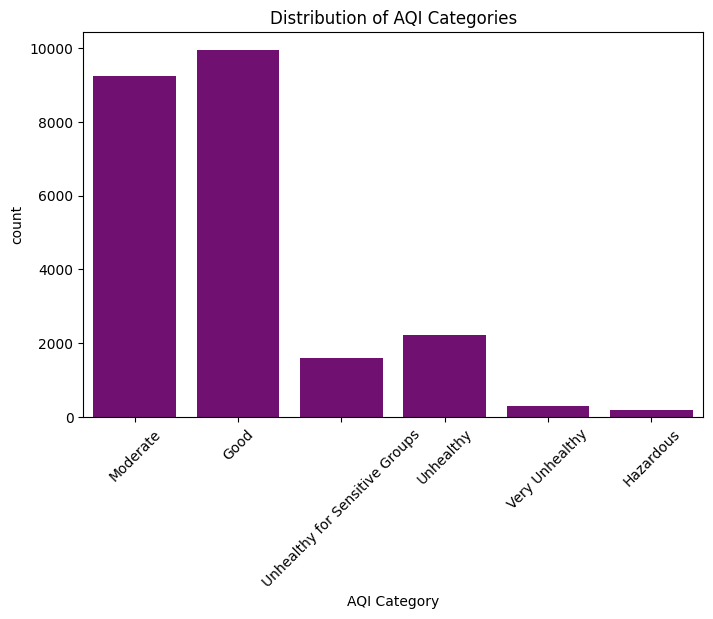

In [53]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="AQI Category",
    data=df2,
    color="purple"
)

plt.xticks(rotation=45)
plt.title("Distribution of AQI Categories")

plt.show()

- This graph shows the number of observations in each AQI category.

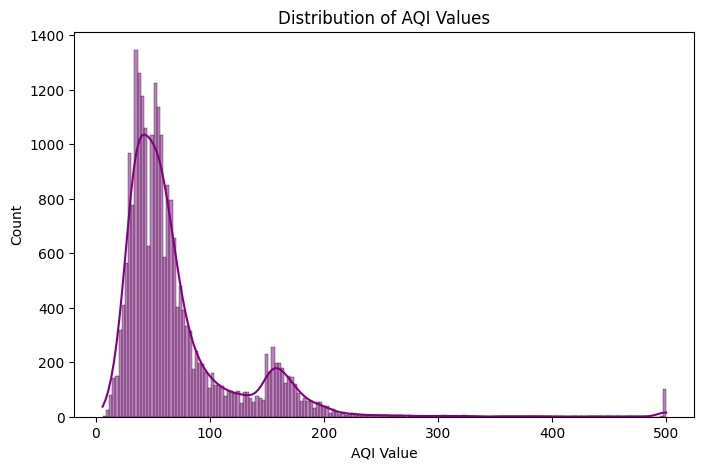

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2["AQI Value"],
    kde=True,
    color="purple"
)

plt.title("Distribution of AQI Values")

plt.show()

- The histogram shows how AQI values are distributed and whether the data is skewed.

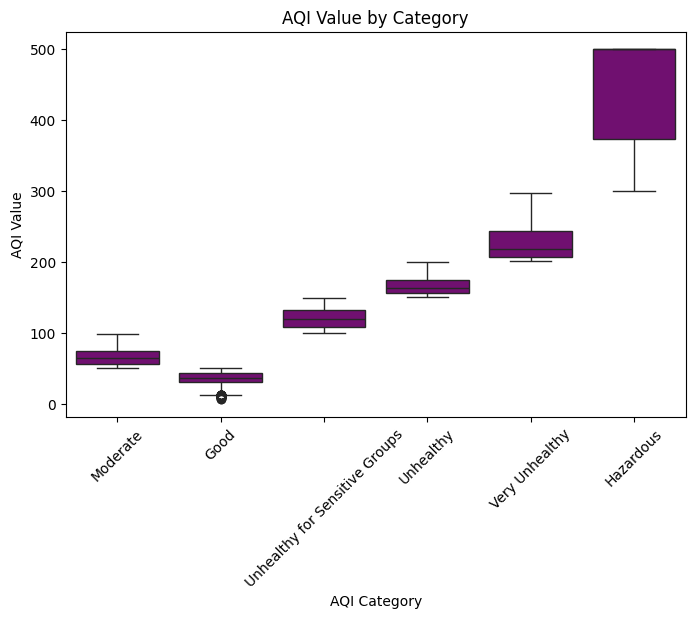

In [55]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="AQI Category",
    y="AQI Value",
    data=df2,
    color="purple"
)

plt.xticks(rotation=45)
plt.title("AQI Value by Category")

plt.show()

- Higher AQI categories generally have higher AQI values.

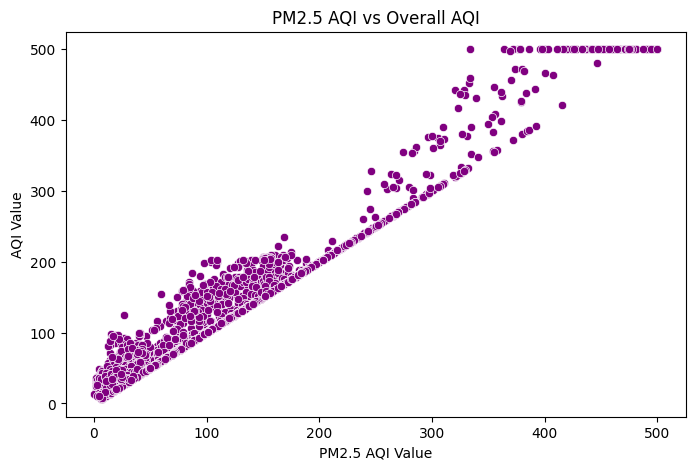

In [56]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="PM2.5 AQI Value",
    y="AQI Value",
    data=df2,
    color="purple"
)

plt.title("PM2.5 AQI vs Overall AQI")

plt.show()

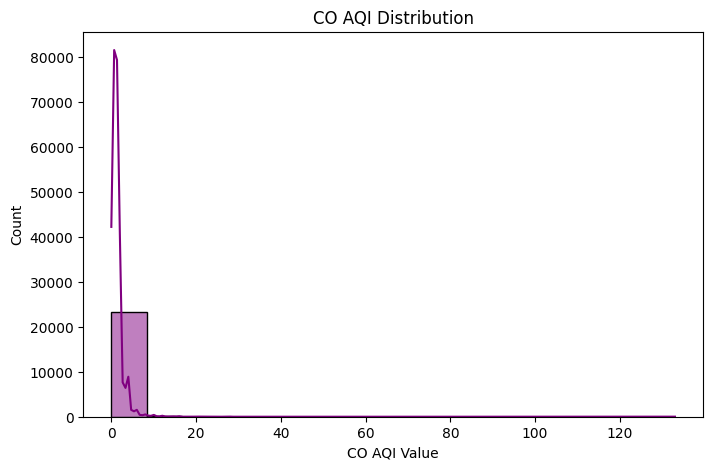

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2["CO AQI Value"],
    kde=True,
    color="purple"
)

plt.title("CO AQI Distribution")

plt.show()

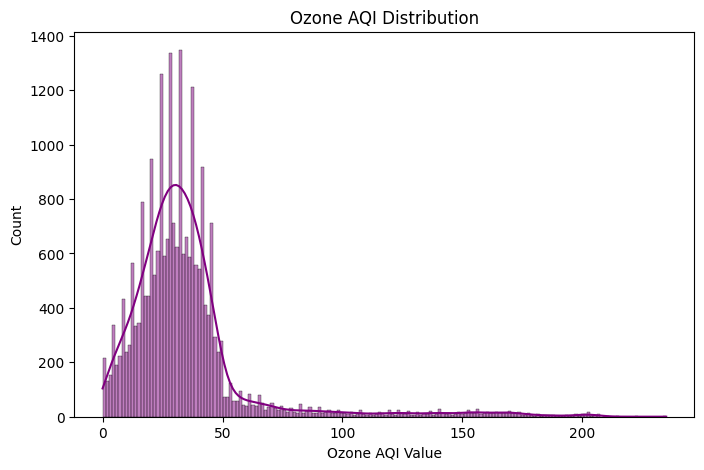

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2["Ozone AQI Value"],
    kde=True,
    color="purple"
)

plt.title("Ozone AQI Distribution")

plt.show()

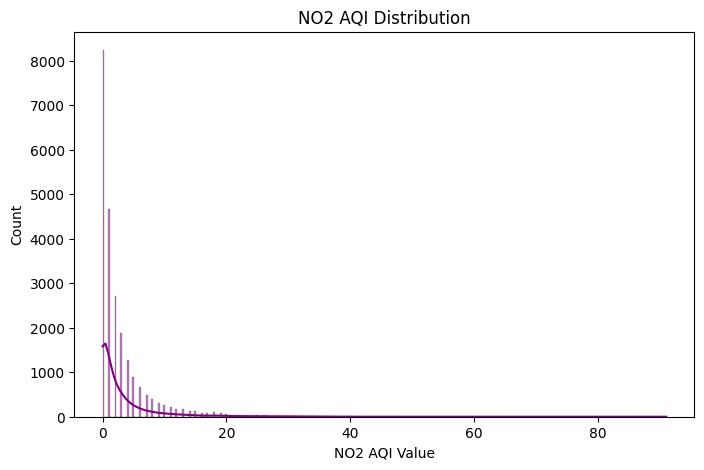

In [59]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2["NO2 AQI Value"],
    kde=True,
    color="purple"
)

plt.title("NO2 AQI Distribution")

plt.show()

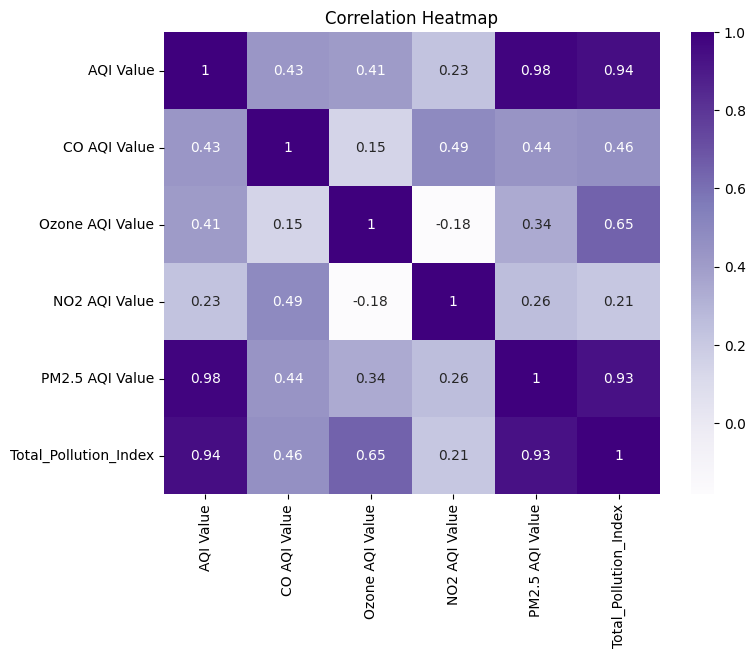

In [60]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df2.corr(numeric_only=True),
    annot=True,
    cmap="Purples"
)

plt.title("Correlation Heatmap")

plt.show()

- The heatmap helps identify strong positive and negative relationships among numerical pollution indicators.

In [61]:
scaler = StandardScaler()

num_cols = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value",
    "Total_Pollution_Index"
]

df2[num_cols] = scaler.fit_transform(df2[num_cols])

df2.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Total_Pollution_Index
0,Russian Federation,Praskoveya,-0.374832,Moderate,-0.201071,Good,0.028696,Good,-0.583048,Good,-0.319731,Moderate,-0.282695
1,Brazil,Presidente Dutra,-0.553232,Good,-0.201071,Good,-1.074581,Good,-0.392717,Good,-0.502229,Good,-0.844011
2,Italy,Priolo Gargallo,-0.107233,Moderate,-0.201071,Good,0.135464,Good,-0.202386,Good,-0.045985,Moderate,-0.002037
3,Poland,Przasnysz,-0.678111,Good,-0.201071,Good,-0.042484,Good,-0.583048,Good,-0.885473,Good,-0.745781
4,France,Punaauia,-0.892190,Good,-0.746915,Good,-0.469558,Good,-0.583048,Good,-1.140970,Good,-1.124670


- Numerical features were standardized so that all variables contribute equally to the model.

In [62]:
encoder = LabelEncoder()

cat_cols = [
    "Country",
    "City",
    "CO AQI Category",
    "Ozone AQI Category",
    "NO2 AQI Category",
    "PM2.5 AQI Category",
    "AQI Category"
]

for col in cat_cols:
    df2[col] = encoder.fit_transform(df2[col])

df2.head()

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Total_Pollution_Index
0,130,16525,-0.374832,2,-0.201071,0,0.028696,0,-0.583048,0,-0.319731,2,-0.282695
1,22,16546,-0.553232,0,-0.201071,0,-1.074581,0,-0.392717,0,-0.502229,0,-0.844011
2,75,16582,-0.107233,2,-0.201071,0,0.135464,0,-0.202386,0,-0.045985,2,-0.002037
3,123,16618,-0.678111,0,-0.201071,0,-0.042484,0,-0.583048,0,-0.885473,0,-0.745781
4,54,16699,-0.892190,0,-0.746915,0,-0.469558,0,-0.583048,0,-1.140970,0,-1.124670


- Categorical columns were converted into numerical values because Logistic Regression requires numerical inputs.

In [63]:
X = df2.drop("AQI Category", axis=1)

y = df2["AQI Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(18770, 12)
(4693, 12)


In [64]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8715107607074366


In [66]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2012    1    1    0    0    0]
 [   0    0    0   42    0    0]
 [  41   22 1767    7    0    0]
 [   0    1  107  311    0    0]
 [   1    1  251   67    0    1]
 [   0    0    1   59    0    0]]


In [67]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2014
           1       0.00      0.00      0.00        42
           2       0.83      0.96      0.89      1837
           3       0.64      0.74      0.69       419
           4       0.00      0.00      0.00       321
           5       0.00      0.00      0.00        60

    accuracy                           0.87      4693
   macro avg       0.41      0.45      0.43      4693
weighted avg       0.80      0.87      0.83      4693



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model Insights

- Accuracy measures the percentage of correctly classified observations.
- Precision indicates how many predicted positive instances are actually correct.
- Recall measures the model's ability to identify all relevant instances.
- F1-Score provides a balance between Precision and Recall.
- The Confusion Matrix shows correct and incorrect classifications for each category.

A higher Accuracy, Precision, Recall, and F1-Score indicate better classification performance.

## Summary

- In this notebook, two sustainability datasets were analyzed using different machine learning approaches.

- For the Climate Change Impact on Agriculture dataset, Linear Regression was used to predict crop yield. Data preprocessing included handling missing values, feature engineering, visualization, scaling, encoding, and model evaluation using MAE, MSE, RMSE, and R² Score.

- For the Global Air Pollution dataset, Logistic Regression was applied to classify AQI categories. Missing values were handled, a new feature (Total_Pollution_Index) was created, visualizations were generated, numerical features were scaled, categorical variables were encoded, and the model was evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.

- This project demonstrates a complete machine learning workflow on two real-world Green Skills and Sustainability datasets, highlighting the importance of data preprocessing, feature engineering, visualization, and appropriate model selection for both regression and classification problems.